# Deep Learning Classifiers for the Dyslexia Dataset

This notebook trains and evaluates `DNN` and `DeepLSE` on the desktop dyslexia dataset with a consistent experiment matrix:

- Baseline
- mRMR-165
- ADASYN-only
- ADASYN + mRMR-165

Each model is evaluated with:

- An 80/20 stratified holdout split
- Stratified 10-fold cross-validation

All reported classification metrics use a split-specific threshold selected from the precision-recall curve.


In [8]:
%pip install -q livelossplot mrmr-selection imbalanced-learn kagglehub seaborn

import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from imblearn.over_sampling import ADASYN
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    from mrmr import mrmr_classif
except ImportError:
    try:
        from mrmr_selection import mrmr_classif
    except ImportError as exc:
        raise ImportError(
            "Unable to import mrmr_classif. Ensure `mrmr-selection` is installed in the notebook runtime."
        ) from exc

RANDOM_STATE = 42
N_SPLITS = 10
HOLDOUT_TEST_SIZE = 0.2
MRMR_K = 165
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
DEEPLSE_LAMBDA_VALUES = [round(value / 10, 1) for value in range(1, 11)]
DEEPLSE_LATENT_VALUES = list(range(10, 65, 5))
SUMMARY_OUTPUT_PATH = Path("/Users/almaan/Downloads/dl_classifiers_summary.csv")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_STATE)
print(f"Using device: {DEVICE}")


Using device: cuda


## Data Preprocessing

Load the desktop dataset, encode categorical columns, remove duplicates, and define the canonical feature matrix `X` and label vector `y`.


In [9]:
def prepare_desktop_data():
    dataset_path = Path(kagglehub.dataset_download("luzrello/dyslexia"))
    df_desktop = pd.read_csv(dataset_path / "Dyt-desktop.csv", delimiter=";")

    categorical_columns = df_desktop.select_dtypes(include=["object"]).columns.tolist()
    for column in categorical_columns:
        encoder = LabelEncoder()
        df_desktop[column] = encoder.fit_transform(df_desktop[column].astype(str))

    duplicate_count = int(df_desktop.duplicated().sum())
    if duplicate_count:
        df_desktop = df_desktop.drop_duplicates().reset_index(drop=True)

    X = df_desktop.drop(columns=["Dyslexia"]).copy()
    y = df_desktop["Dyslexia"].astype(int).copy()
    return df_desktop, X, y, dataset_path, categorical_columns, duplicate_count


df_desktop, X, y, DATASET_PATH, ENCODED_COLUMNS, DUPLICATE_COUNT = prepare_desktop_data()

print(f"Dataset path: {DATASET_PATH}")
print(f"Desktop shape: {df_desktop.shape}")
print(f"Feature count: {X.shape[1]}")
print(f"Encoded columns: {ENCODED_COLUMNS}")
print(f"Duplicates removed: {DUPLICATE_COUNT}")
print("Target distribution:")
print((y.value_counts(normalize=True) * 100).round(2))
display(df_desktop.head())


Using Colab cache for faster access to the 'dyslexia' dataset.
Dataset path: /kaggle/input/dyslexia
Desktop shape: (3644, 197)
Feature count: 196
Encoded columns: ['Gender', 'Nativelang', 'Otherlang', 'Dyslexia']
Duplicates removed: 0
Target distribution:
Dyslexia
0    89.24
1    10.76
Name: proportion, dtype: float64


,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,...,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32,Dyslexia
0,1,0,1,7,10,10,0,10,1.0,0.0,...,0,0.000000,0.00,17,2,0,2,0.117647,0.000000,0
1,0,1,1,13,12,12,0,12,1.0,0.0,...,4,0.114286,0.00,26,2,2,2,0.076923,0.076923,1
2,0,0,1,7,6,6,0,6,1.0,0.0,...,4,0.114286,0.00,26,1,3,1,0.038462,0.115385,0
3,0,0,1,7,0,0,0,0,0.0,0.0,...,0,0.000000,0.00,1,0,0,0,0.000000,0.000000,0
4,0,0,1,8,4,4,0,4,1.0,0.0,...,1,25.000000,0.05,26,2,2,2,0.076923,0.076923,0


## Model Definitions

Define `DNN` and `DeepLSE` so each experiment starts from a fresh model state.


In [10]:
class DNN(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


class DeepLSE(nn.Module):
    def __init__(self, input_shape: int, LV: int = 5):
        super().__init__()
        self.enc_l1 = nn.Sequential(
            nn.Linear(input_shape, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
        )
        self.enc_l2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
        )
        self.enc_l3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),
        )
        self.encoder_output = nn.Sequential(
            nn.Linear(32, LV),
            nn.Sigmoid(),
        )

        self.class_l1 = nn.Sequential(
            nn.Linear(LV, 64),
            nn.ReLU(),
        )
        self.class_l2 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.class_output = nn.Linear(32, 1)

        self.dec_l1 = nn.Sequential(
            nn.Linear(LV, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),
        )
        self.dec_l2 = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
        )
        self.dec_l3 = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
        )
        self.decoder_output = nn.Linear(128, input_shape)

    def forward(self, x):
        enc_l1_out = self.enc_l1(x)
        enc_l2_out = self.enc_l2(enc_l1_out)
        enc_l3_out = self.enc_l3(enc_l2_out)
        encoder_out = self.encoder_output(enc_l3_out)

        class_l1_out = self.class_l1(encoder_out)
        class_l2_out = self.class_l2(class_l1_out)
        class_out = self.class_output(class_l2_out)

        dec_l1_out = self.dec_l1(encoder_out)
        dec_l2_out = self.dec_l2(dec_l1_out)
        dec_l3_out = self.dec_l3(dec_l2_out)
        decoder_out = self.decoder_output(dec_l3_out)

        return class_out, decoder_out


def reset_weights(module: nn.Module) -> None:
    if hasattr(module, "reset_parameters"):
        module.reset_parameters()


## Helper Functions

Shared preprocessing, training, thresholding, and metric helpers used by every experiment path.


In [11]:
def build_classification_loss(y_train, use_adasyn: bool = False, device: torch.device = DEVICE):
    if use_adasyn:
        return nn.BCEWithLogitsLoss()

    y_array = np.asarray(y_train).astype(int).ravel()
    pos_count = int((y_array == 1).sum())
    neg_count = int((y_array == 0).sum())
    if pos_count == 0 or neg_count == 0:
        return nn.BCEWithLogitsLoss()

    pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32, device=device)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def select_features_mrmr(X_train_df: pd.DataFrame, y_train: pd.Series, k: int = MRMR_K):
    k = min(k, X_train_df.shape[1])
    selected_columns = mrmr_classif(X=X_train_df, y=y_train, K=k)
    return list(selected_columns)


def scale_features(X_train_df: pd.DataFrame, X_eval_df: pd.DataFrame):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_df)
    X_eval_scaled = scaler.transform(X_eval_df)
    return X_train_scaled.astype(np.float32), X_eval_scaled.astype(np.float32), scaler


def oversample_with_adasyn(X_train_scaled, y_train, random_state: int = RANDOM_STATE):
    y_series = pd.Series(np.asarray(y_train).astype(int).ravel())
    class_counts = y_series.value_counts()
    if class_counts.shape[0] < 2:
        return np.asarray(X_train_scaled, dtype=np.float32), y_series.to_numpy(dtype=np.float32)

    minority_count = int(class_counts.min())
    if minority_count < 2:
        return np.asarray(X_train_scaled, dtype=np.float32), y_series.to_numpy(dtype=np.float32)

    n_neighbors = max(1, min(5, minority_count - 1))
    adasyn = ADASYN(random_state=random_state, n_neighbors=n_neighbors)
    X_resampled, y_resampled = adasyn.fit_resample(X_train_scaled, y_series.to_numpy())
    return np.asarray(X_resampled, dtype=np.float32), np.asarray(y_resampled, dtype=np.float32)


def prepare_variant_features(
    X_train_df: pd.DataFrame,
    X_eval_df: pd.DataFrame,
    y_train: pd.Series,
    use_mrmr: bool = False,
    use_adasyn: bool = False,
    mrmr_k: int = MRMR_K,
    random_state: int = RANDOM_STATE,
):
    selected_columns = list(X_train_df.columns)
    if use_mrmr:
        selected_columns = select_features_mrmr(X_train_df, y_train, k=mrmr_k)

    X_train_selected = X_train_df[selected_columns].copy()
    X_eval_selected = X_eval_df[selected_columns].copy()
    X_train_scaled, X_eval_scaled, _ = scale_features(X_train_selected, X_eval_selected)

    y_train_array = np.asarray(y_train, dtype=np.float32).ravel()
    if use_adasyn:
        X_train_scaled, y_train_array = oversample_with_adasyn(
            X_train_scaled,
            y_train_array,
            random_state=random_state,
        )

    return X_train_scaled, X_eval_scaled, y_train_array, selected_columns


def compute_optimal_threshold(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).astype(float).ravel()
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = float(auc(recall[::-1], precision[::-1]))

    if len(thresholds) == 0:
        return 0.5, precision, recall, pr_auc

    f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
    f1_scores = np.nan_to_num(f1_scores, nan=0.0, posinf=0.0, neginf=0.0)
    best_index = int(np.argmax(f1_scores))
    return float(thresholds[best_index]), precision, recall, pr_auc


def compute_metrics(y_true, y_prob, threshold: float):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).astype(float).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist(),
    }


def plot_pr_curve(precision, recall, pr_auc: float, title: str):
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def to_tensor(array_like):
    return torch.tensor(array_like, dtype=torch.float32, device=DEVICE)


def train_dnn_model(
    X_train,
    y_train,
    input_size: int,
    num_epochs: int = NUM_EPOCHS,
    learning_rate: float = LEARNING_RATE,
    seed: int = RANDOM_STATE,
    use_adasyn: bool = False,
):
    set_seed(seed)
    model = DNN(input_size).to(DEVICE)
    model.apply(reset_weights)
    criterion = build_classification_loss(y_train, use_adasyn=use_adasyn, device=DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    X_train_tensor = to_tensor(X_train)
    y_train_tensor = to_tensor(np.asarray(y_train, dtype=np.float32).reshape(-1, 1))

    for _ in range(num_epochs):
        model.train()
        logits = model(X_train_tensor)
        loss = criterion(logits, y_train_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model


def predict_dnn_probabilities(model, X_eval):
    model.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(model(to_tensor(X_eval)))
    return probabilities.detach().cpu().numpy().ravel()


def train_deeplse_model(
    X_train,
    y_train,
    input_size: int,
    lambd: float,
    latent_var: int,
    num_epochs: int = NUM_EPOCHS,
    learning_rate: float = LEARNING_RATE,
    seed: int = RANDOM_STATE,
    use_adasyn: bool = False,
):
    set_seed(seed)
    model = DeepLSE(input_size, LV=latent_var).to(DEVICE)
    model.apply(reset_weights)

    classification_loss = build_classification_loss(y_train, use_adasyn=use_adasyn, device=DEVICE)
    reconstruction_loss = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    X_train_tensor = to_tensor(X_train)
    y_train_tensor = to_tensor(np.asarray(y_train, dtype=np.float32).reshape(-1, 1))

    for _ in range(num_epochs):
        model.train()
        class_logits, decoder_output = model(X_train_tensor)
        class_loss_value = classification_loss(class_logits, y_train_tensor)
        reconstruction_loss_value = reconstruction_loss(decoder_output, X_train_tensor)
        loss = lambd * class_loss_value + (1 - lambd) * reconstruction_loss_value

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model


def predict_deeplse_probabilities(model, X_eval):
    model.eval()
    with torch.no_grad():
        class_logits, _ = model(to_tensor(X_eval))
        probabilities = torch.sigmoid(class_logits)
    return probabilities.detach().cpu().numpy().ravel()


## Experiment Drivers

The same variant-preprocessing flow is used for both holdout and stratified K-fold runs.


In [12]:
VARIANT_SPECS = [
    {"name": "baseline", "label": "Baseline", "use_mrmr": False, "use_adasyn": False},
    {"name": "mrmr_165", "label": "mRMR-165", "use_mrmr": True, "use_adasyn": False},
    {"name": "adasyn_only", "label": "ADASYN-only", "use_mrmr": False, "use_adasyn": True},
    {"name": "adasyn_mrmr_165", "label": "ADASYN + mRMR-165", "use_mrmr": True, "use_adasyn": True},
]


def initialize_result_row(model_name, variant_spec, evaluation_mode, selected_feature_count, deep_params=None):
    deep_params = deep_params or {}
    return {
        "model": model_name,
        "variant": variant_spec["label"],
        "evaluation_mode": evaluation_mode,
        "selected_feature_count": int(selected_feature_count),
        "mrmr_used": bool(variant_spec["use_mrmr"]),
        "adasyn_used": bool(variant_spec["use_adasyn"]),
        "lambda": deep_params.get("lambd", np.nan),
        "latent_var": deep_params.get("latent_var", np.nan),
        "threshold": np.nan,
        "accuracy": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "f1": np.nan,
        "pr_auc": np.nan,
        "threshold_mean": np.nan,
        "threshold_std": np.nan,
        "accuracy_mean": np.nan,
        "accuracy_std": np.nan,
        "precision_mean": np.nan,
        "precision_std": np.nan,
        "recall_mean": np.nan,
        "recall_std": np.nan,
        "f1_mean": np.nan,
        "f1_std": np.nan,
        "pr_auc_mean": np.nan,
        "pr_auc_std": np.nan,
        "confusion_matrix": np.nan,
        "num_folds": 1 if evaluation_mode == "holdout" else N_SPLITS,
    }


def summarize_kfold_metrics(model_name, variant_spec, fold_metrics, selected_feature_count, deep_params=None):
    fold_metrics_df = pd.DataFrame(fold_metrics)
    confusion_matrices = [np.asarray(metric["confusion_matrix"], dtype=int) for metric in fold_metrics]
    result_row = initialize_result_row(
        model_name,
        variant_spec,
        evaluation_mode="stratified_kfold",
        selected_feature_count=selected_feature_count,
        deep_params=deep_params,
    )
    result_row.update(
        {
            "threshold_mean": float(fold_metrics_df["threshold"].mean()),
            "threshold_std": float(fold_metrics_df["threshold"].std(ddof=0)),
            "accuracy_mean": float(fold_metrics_df["accuracy"].mean()),
            "accuracy_std": float(fold_metrics_df["accuracy"].std(ddof=0)),
            "precision_mean": float(fold_metrics_df["precision"].mean()),
            "precision_std": float(fold_metrics_df["precision"].std(ddof=0)),
            "recall_mean": float(fold_metrics_df["recall"].mean()),
            "recall_std": float(fold_metrics_df["recall"].std(ddof=0)),
            "f1_mean": float(fold_metrics_df["f1"].mean()),
            "f1_std": float(fold_metrics_df["f1"].std(ddof=0)),
            "pr_auc_mean": float(fold_metrics_df["pr_auc"].mean()),
            "pr_auc_std": float(fold_metrics_df["pr_auc"].std(ddof=0)),
            "confusion_matrix": np.sum(confusion_matrices, axis=0).tolist(),
        }
    )
    return result_row, fold_metrics_df


def build_variant_fold_cache(variant_spec, X_df, y_series):
    skfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    prepared_folds = []

    for fold_index, (train_index, val_index) in enumerate(skfold.split(X_df, y_series), start=1):
        X_train_df = X_df.iloc[train_index].copy()
        X_val_df = X_df.iloc[val_index].copy()
        y_train = y_series.iloc[train_index].copy()
        y_val = y_series.iloc[val_index].copy()

        X_train_processed, X_val_processed, y_train_processed, selected_columns = prepare_variant_features(
            X_train_df,
            X_val_df,
            y_train,
            use_mrmr=variant_spec["use_mrmr"],
            use_adasyn=variant_spec["use_adasyn"],
            mrmr_k=MRMR_K,
            random_state=RANDOM_STATE + fold_index,
        )

        prepared_folds.append(
            {
                "fold_index": fold_index,
                "X_train": X_train_processed,
                "X_eval": X_val_processed,
                "y_train": np.asarray(y_train_processed, dtype=np.float32).ravel(),
                "y_eval": np.asarray(y_val, dtype=np.float32).ravel(),
                "selected_columns": selected_columns,
                "selected_feature_count": len(selected_columns),
            }
        )

    return prepared_folds


def run_holdout_experiment(model_name, variant_spec, X_df, y_series, deep_params=None, plot_curve=True):
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        X_df,
        y_series,
        test_size=HOLDOUT_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_series,
    )

    X_train_processed, X_test_processed, y_train_processed, selected_columns = prepare_variant_features(
        X_train_df,
        X_test_df,
        y_train,
        use_mrmr=variant_spec["use_mrmr"],
        use_adasyn=variant_spec["use_adasyn"],
        mrmr_k=MRMR_K,
        random_state=RANDOM_STATE,
    )

    if model_name == "DNN":
        model = train_dnn_model(
            X_train_processed,
            y_train_processed,
            input_size=len(selected_columns),
            seed=RANDOM_STATE,
            use_adasyn=variant_spec["use_adasyn"],
        )
        y_prob = predict_dnn_probabilities(model, X_test_processed)
    else:
        model = train_deeplse_model(
            X_train_processed,
            y_train_processed,
            input_size=len(selected_columns),
            lambd=deep_params["lambd"],
            latent_var=deep_params["latent_var"],
            seed=RANDOM_STATE,
            use_adasyn=variant_spec["use_adasyn"],
        )
        y_prob = predict_deeplse_probabilities(model, X_test_processed)

    threshold, precision_curve, recall_curve, pr_auc = compute_optimal_threshold(y_test, y_prob)
    metrics = compute_metrics(y_test, y_prob, threshold)

    if plot_curve:
        plot_title = f"{model_name} | {variant_spec['label']} | Holdout Precision-Recall Curve"
        plot_pr_curve(precision_curve, recall_curve, pr_auc, plot_title)

    result_row = initialize_result_row(
        model_name,
        variant_spec,
        evaluation_mode="holdout",
        selected_feature_count=len(selected_columns),
        deep_params=deep_params,
    )
    result_row.update(
        {
            "threshold": metrics["threshold"],
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "pr_auc": pr_auc,
            "confusion_matrix": metrics["confusion_matrix"],
        }
    )
    return result_row


def run_stratified_kfold_experiment(model_name, variant_spec, X_df=None, y_series=None, deep_params=None, prepared_folds=None):
    if prepared_folds is None:
        if X_df is None or y_series is None:
            raise ValueError("X_df and y_series are required when prepared_folds is not provided.")
        prepared_folds = build_variant_fold_cache(variant_spec, X_df, y_series)

    fold_metrics = []
    selected_feature_count = prepared_folds[0]["selected_feature_count"]

    for prepared_fold in prepared_folds:
        fold_index = prepared_fold["fold_index"]
        X_train_processed = prepared_fold["X_train"]
        X_val_processed = prepared_fold["X_eval"]
        y_train_processed = prepared_fold["y_train"]
        y_val = prepared_fold["y_eval"]

        if model_name == "DNN":
            model = train_dnn_model(
                X_train_processed,
                y_train_processed,
                input_size=selected_feature_count,
                seed=RANDOM_STATE + fold_index,
                use_adasyn=variant_spec["use_adasyn"],
            )
            y_prob = predict_dnn_probabilities(model, X_val_processed)
        else:
            model = train_deeplse_model(
                X_train_processed,
                y_train_processed,
                input_size=selected_feature_count,
                lambd=deep_params["lambd"],
                latent_var=deep_params["latent_var"],
                seed=RANDOM_STATE + fold_index,
                use_adasyn=variant_spec["use_adasyn"],
            )
            y_prob = predict_deeplse_probabilities(model, X_val_processed)

        threshold, _, _, pr_auc = compute_optimal_threshold(y_val, y_prob)
        metrics = compute_metrics(y_val, y_prob, threshold)
        metrics["pr_auc"] = pr_auc
        fold_metrics.append(metrics)

    return summarize_kfold_metrics(
        model_name,
        variant_spec,
        fold_metrics,
        selected_feature_count=selected_feature_count,
        deep_params=deep_params,
    )


def run_deeplse_grid_search(variant_spec, prepared_folds):
    grid_search_rows = []
    best_result = None
    best_score = -np.inf
    total_combinations = len(DEEPLSE_LAMBDA_VALUES) * len(DEEPLSE_LATENT_VALUES)
    combination_counter = 0

    for lambd in DEEPLSE_LAMBDA_VALUES:
        for latent_var in DEEPLSE_LATENT_VALUES:
            combination_counter += 1
            if combination_counter == 1 or combination_counter % 10 == 0 or combination_counter == total_combinations:
                print(
                    f"DeepLSE grid search | {variant_spec['label']} | "
                    f"{combination_counter}/{total_combinations} | lambda={lambd}, latent_var={latent_var}"
                )

            deep_params = {"lambd": lambd, "latent_var": latent_var}
            cv_result, _ = run_stratified_kfold_experiment(
                "DeepLSE",
                variant_spec,
                deep_params=deep_params,
                prepared_folds=prepared_folds,
            )
            grid_search_rows.append(cv_result)

            if cv_result["f1_mean"] > best_score:
                best_score = cv_result["f1_mean"]
                best_result = cv_result.copy()

    grid_search_df = pd.DataFrame(grid_search_rows).sort_values(
        by=["f1_mean", "pr_auc_mean"],
        ascending=[False, False],
    ).reset_index(drop=True)
    return best_result, grid_search_df


## Run the Full Experiment Matrix

This cell runs every requested experiment. It is designed to be executed with `Run All`, but it will take a long time because DeepLSE performs a per-variant grid search with stratified 10-fold CV.


Running DNN holdout experiment: Baseline


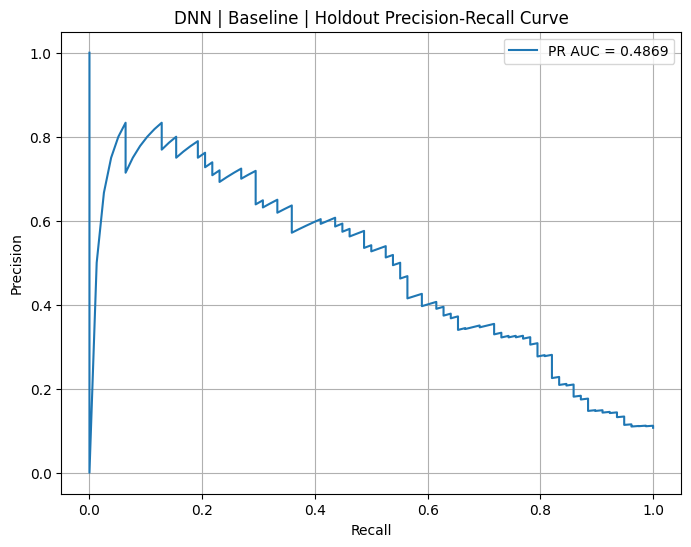

Running DNN stratified k-fold experiment: Baseline
Running DNN holdout experiment: mRMR-165


100%|██████████| 165/165 [00:20<00:00,  8.23it/s]


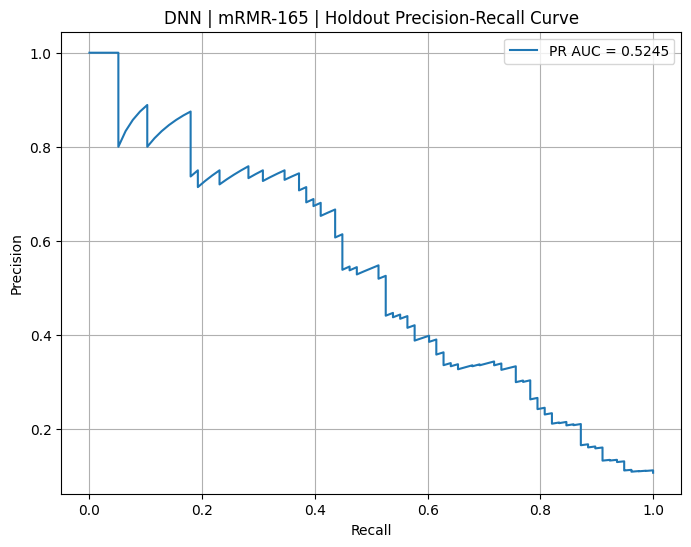

Running DNN stratified k-fold experiment: mRMR-165


100%|██████████| 165/165 [00:21<00:00,  7.84it/s]


Running DNN holdout experiment: ADASYN-only


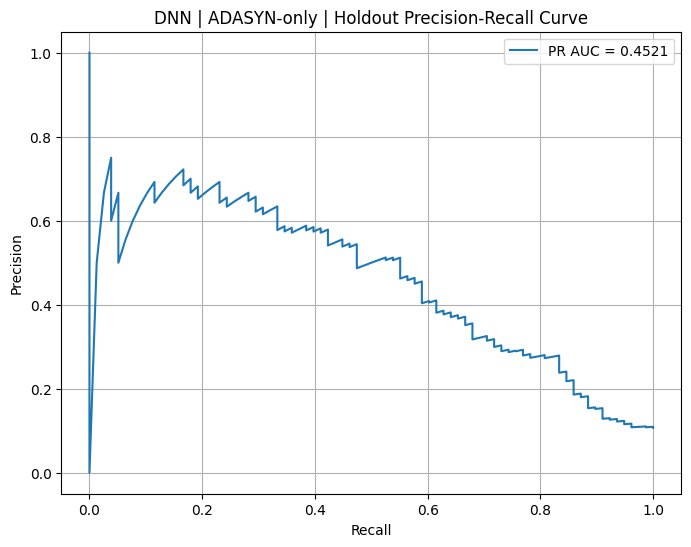

Running DNN stratified k-fold experiment: ADASYN-only
Running DNN holdout experiment: ADASYN + mRMR-165


100%|██████████| 165/165 [00:20<00:00,  8.21it/s]


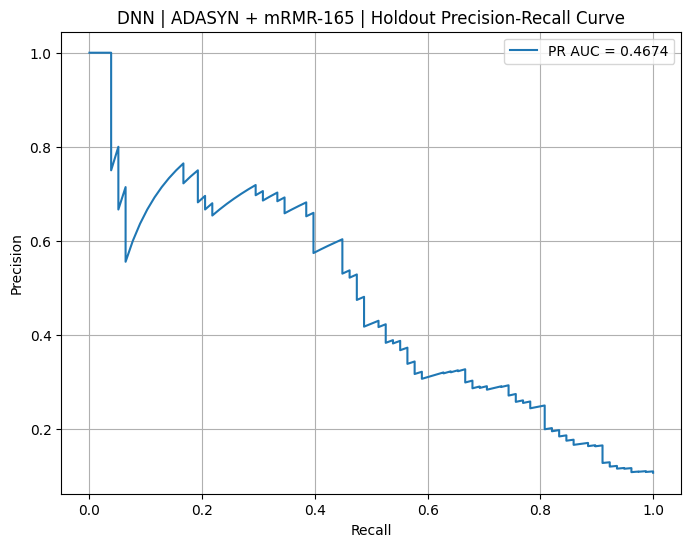

Running DNN stratified k-fold experiment: ADASYN + mRMR-165


100%|██████████| 165/165 [00:19<00:00,  8.46it/s]


Preparing DeepLSE folds once: Baseline
Running DeepLSE grid search: Baseline
DeepLSE grid search | Baseline | 1/110 | lambda=0.1, latent_var=10
DeepLSE grid search | Baseline | 10/110 | lambda=0.1, latent_var=55
DeepLSE grid search | Baseline | 20/110 | lambda=0.2, latent_var=50
DeepLSE grid search | Baseline | 30/110 | lambda=0.3, latent_var=45
DeepLSE grid search | Baseline | 40/110 | lambda=0.4, latent_var=40
DeepLSE grid search | Baseline | 50/110 | lambda=0.5, latent_var=35
DeepLSE grid search | Baseline | 60/110 | lambda=0.6, latent_var=30
DeepLSE grid search | Baseline | 70/110 | lambda=0.7, latent_var=25
DeepLSE grid search | Baseline | 80/110 | lambda=0.8, latent_var=20
DeepLSE grid search | Baseline | 90/110 | lambda=0.9, latent_var=15
DeepLSE grid search | Baseline | 100/110 | lambda=1.0, latent_var=10
DeepLSE grid search | Baseline | 110/110 | lambda=1.0, latent_var=60
Best DeepLSE config for Baseline: lambda=0.9, latent_var=15, mean F1=0.5739
Saving DeepLSE fold metrics fo

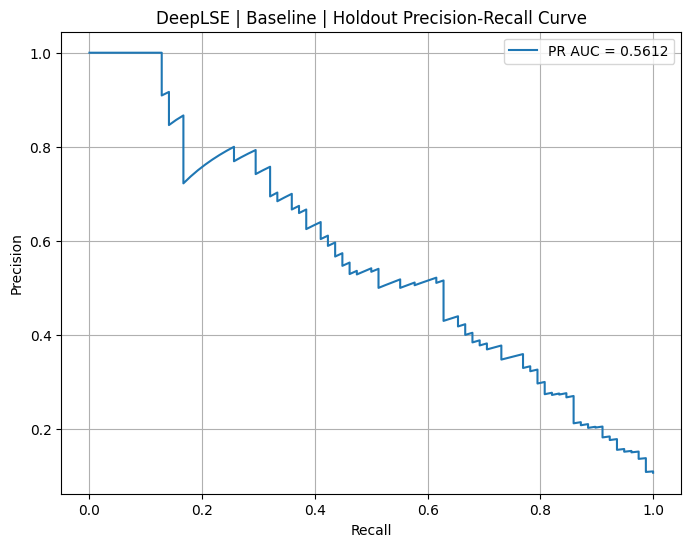

Preparing DeepLSE folds once: mRMR-165


100%|██████████| 165/165 [00:21<00:00,  7.67it/s]


Running DeepLSE grid search: mRMR-165
DeepLSE grid search | mRMR-165 | 1/110 | lambda=0.1, latent_var=10
DeepLSE grid search | mRMR-165 | 10/110 | lambda=0.1, latent_var=55
DeepLSE grid search | mRMR-165 | 20/110 | lambda=0.2, latent_var=50
DeepLSE grid search | mRMR-165 | 30/110 | lambda=0.3, latent_var=45
DeepLSE grid search | mRMR-165 | 40/110 | lambda=0.4, latent_var=40
DeepLSE grid search | mRMR-165 | 50/110 | lambda=0.5, latent_var=35
DeepLSE grid search | mRMR-165 | 60/110 | lambda=0.6, latent_var=30
DeepLSE grid search | mRMR-165 | 70/110 | lambda=0.7, latent_var=25
DeepLSE grid search | mRMR-165 | 80/110 | lambda=0.8, latent_var=20
DeepLSE grid search | mRMR-165 | 90/110 | lambda=0.9, latent_var=15
DeepLSE grid search | mRMR-165 | 100/110 | lambda=1.0, latent_var=10
DeepLSE grid search | mRMR-165 | 110/110 | lambda=1.0, latent_var=60
Best DeepLSE config for mRMR-165: lambda=0.7, latent_var=15, mean F1=0.5774
Saving DeepLSE fold metrics for best config: mRMR-165
Running DeepLSE

100%|██████████| 165/165 [00:18<00:00,  9.11it/s]


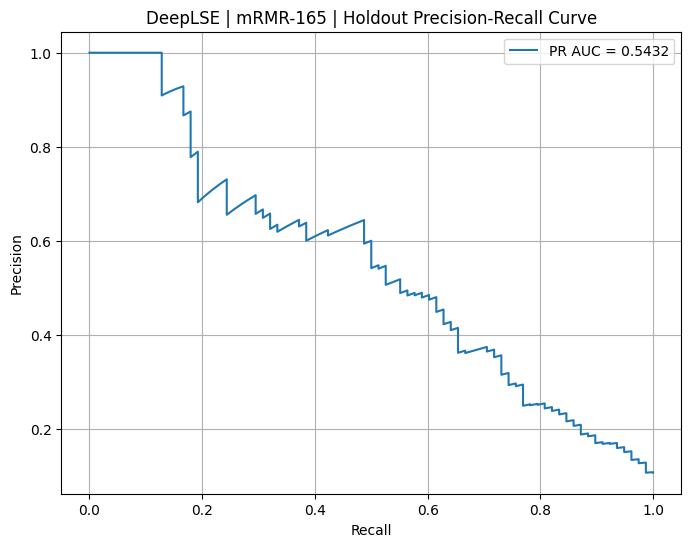

Preparing DeepLSE folds once: ADASYN-only
Running DeepLSE grid search: ADASYN-only
DeepLSE grid search | ADASYN-only | 1/110 | lambda=0.1, latent_var=10
DeepLSE grid search | ADASYN-only | 10/110 | lambda=0.1, latent_var=55
DeepLSE grid search | ADASYN-only | 20/110 | lambda=0.2, latent_var=50
DeepLSE grid search | ADASYN-only | 30/110 | lambda=0.3, latent_var=45
DeepLSE grid search | ADASYN-only | 40/110 | lambda=0.4, latent_var=40
DeepLSE grid search | ADASYN-only | 50/110 | lambda=0.5, latent_var=35
DeepLSE grid search | ADASYN-only | 60/110 | lambda=0.6, latent_var=30
DeepLSE grid search | ADASYN-only | 70/110 | lambda=0.7, latent_var=25
DeepLSE grid search | ADASYN-only | 80/110 | lambda=0.8, latent_var=20
DeepLSE grid search | ADASYN-only | 90/110 | lambda=0.9, latent_var=15
DeepLSE grid search | ADASYN-only | 100/110 | lambda=1.0, latent_var=10
DeepLSE grid search | ADASYN-only | 110/110 | lambda=1.0, latent_var=60
Best DeepLSE config for ADASYN-only: lambda=0.3, latent_var=20, 

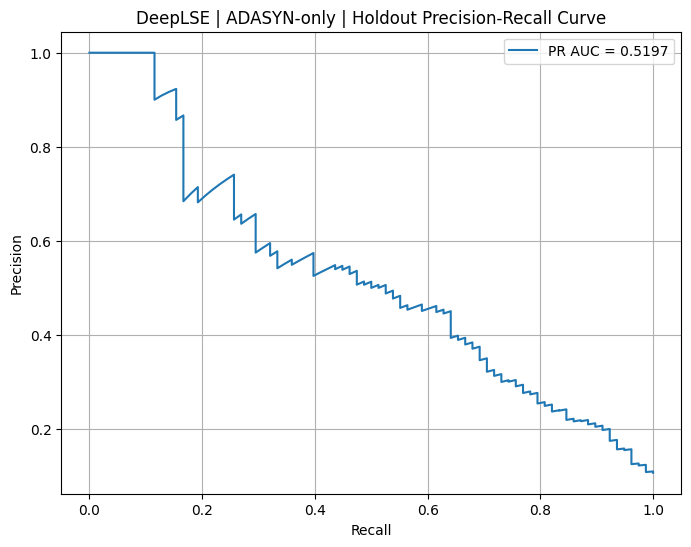

Preparing DeepLSE folds once: ADASYN + mRMR-165


100%|██████████| 165/165 [00:20<00:00,  8.06it/s]


Running DeepLSE grid search: ADASYN + mRMR-165
DeepLSE grid search | ADASYN + mRMR-165 | 1/110 | lambda=0.1, latent_var=10
DeepLSE grid search | ADASYN + mRMR-165 | 10/110 | lambda=0.1, latent_var=55
DeepLSE grid search | ADASYN + mRMR-165 | 20/110 | lambda=0.2, latent_var=50
DeepLSE grid search | ADASYN + mRMR-165 | 30/110 | lambda=0.3, latent_var=45
DeepLSE grid search | ADASYN + mRMR-165 | 40/110 | lambda=0.4, latent_var=40
DeepLSE grid search | ADASYN + mRMR-165 | 50/110 | lambda=0.5, latent_var=35
DeepLSE grid search | ADASYN + mRMR-165 | 60/110 | lambda=0.6, latent_var=30
DeepLSE grid search | ADASYN + mRMR-165 | 70/110 | lambda=0.7, latent_var=25
DeepLSE grid search | ADASYN + mRMR-165 | 80/110 | lambda=0.8, latent_var=20
DeepLSE grid search | ADASYN + mRMR-165 | 90/110 | lambda=0.9, latent_var=15
DeepLSE grid search | ADASYN + mRMR-165 | 100/110 | lambda=1.0, latent_var=10
DeepLSE grid search | ADASYN + mRMR-165 | 110/110 | lambda=1.0, latent_var=60
Best DeepLSE config for ADAS

100%|██████████| 165/165 [00:22<00:00,  7.47it/s]


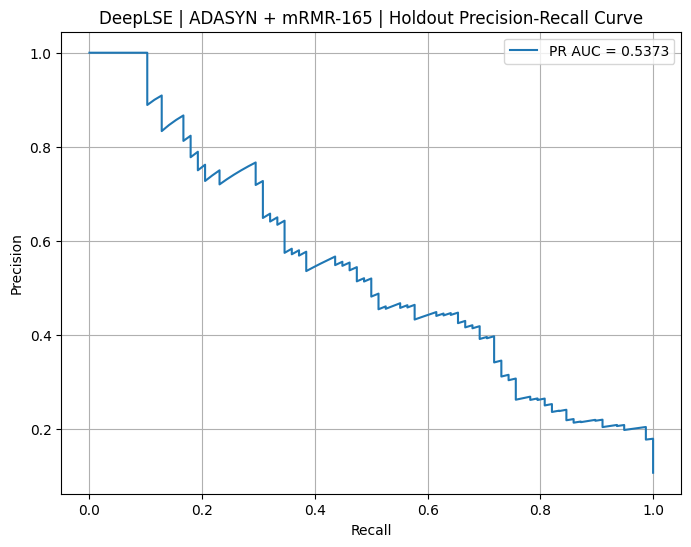

Completed 16 experiment summaries.


In [13]:
all_results = []
dnn_fold_details = {}
deeplse_fold_details = {}
deeplse_grid_search_tables = {}
deeplse_best_configs = {}
deeplse_prepared_folds = {}

for variant_spec in VARIANT_SPECS:
    print(f"Running DNN holdout experiment: {variant_spec['label']}")
    dnn_holdout_result = run_holdout_experiment("DNN", variant_spec, X, y)
    all_results.append(dnn_holdout_result)

    print(f"Running DNN stratified k-fold experiment: {variant_spec['label']}")
    dnn_kfold_result, dnn_fold_df = run_stratified_kfold_experiment("DNN", variant_spec, X_df=X, y_series=y)
    all_results.append(dnn_kfold_result)
    dnn_fold_details[variant_spec["name"]] = dnn_fold_df

for variant_spec in VARIANT_SPECS:
    print(f"Preparing DeepLSE folds once: {variant_spec['label']}")
    prepared_folds = build_variant_fold_cache(variant_spec, X, y)
    deeplse_prepared_folds[variant_spec["name"]] = prepared_folds

    print(f"Running DeepLSE grid search: {variant_spec['label']}")
    best_cv_result, grid_search_df = run_deeplse_grid_search(variant_spec, prepared_folds)
    deeplse_grid_search_tables[variant_spec["name"]] = grid_search_df
    deeplse_best_configs[variant_spec["name"]] = {
        "lambd": float(best_cv_result["lambda"]),
        "latent_var": int(best_cv_result["latent_var"]),
    }
    all_results.append(best_cv_result)
    print(
        f"Best DeepLSE config for {variant_spec['label']}: "
        f"lambda={best_cv_result['lambda']}, latent_var={int(best_cv_result['latent_var'])}, "
        f"mean F1={best_cv_result['f1_mean']:.4f}"
    )

    print(f"Saving DeepLSE fold metrics for best config: {variant_spec['label']}")
    _, deeplse_fold_df = run_stratified_kfold_experiment(
        "DeepLSE",
        variant_spec,
        deep_params=deeplse_best_configs[variant_spec["name"]],
        prepared_folds=prepared_folds,
    )
    deeplse_fold_details[variant_spec["name"]] = deeplse_fold_df

    print(f"Running DeepLSE holdout experiment: {variant_spec['label']}")
    deeplse_holdout_result = run_holdout_experiment(
        "DeepLSE",
        variant_spec,
        X,
        y,
        deep_params=deeplse_best_configs[variant_spec["name"]],
    )
    all_results.append(deeplse_holdout_result)

print(f"Completed {len(all_results)} experiment summaries.")


## Final Summary and Export

Combine every final experiment result into a single summary table, print it, and save it to the local device.


In [19]:
from pathlib import Path
import os

summary_columns = [
    "model",
    "variant",
    "evaluation_mode",
    "selected_feature_count",
    "mrmr_used",
    "adasyn_used",
    "lambda",
    "latent_var",
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "threshold_mean",
    "threshold_std",
    "accuracy_mean",
    "accuracy_std",
    "precision_mean",
    "precision_std",
    "recall_mean",
    "recall_std",
    "f1_mean",
    "f1_std",
    "pr_auc_mean",
    "pr_auc_std",
    "confusion_matrix",
    "num_folds",
]

summary_results = pd.DataFrame(all_results)
summary_results = summary_results.reindex(columns=summary_columns)
summary_results = summary_results.sort_values(
    by=["model", "variant", "evaluation_mode"],
    ascending=[True, True, True],
).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
display(summary_results)

print("Current working directory:", Path.cwd())
print("Home directory:", Path.home())

output_path = Path.home() / "Downloads" / "dl_classifiers_summary.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

summary_results.to_csv(output_path, index=False)

print("Saved summary to:", output_path)
print("File exists:", output_path.exists())
print("Absolute path:", output_path.resolve())


,model,variant,evaluation_mode,selected_feature_count,mrmr_used,adasyn_used,lambda,latent_var,threshold,accuracy,precision,recall,f1,pr_auc,threshold_mean,threshold_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,confusion_matrix,num_folds
0,DNN,ADASYN + mRMR-165,holdout,165,True,True,NaN,NaN,0.221745,0.909465,0.603448,0.448718,0.514706,0.467435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[[628, 23], [43, 35]]",1
1,DNN,ADASYN + mRMR-165,stratified_kfold,165,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129609,0.181933,0.883638,0.029722,0.490468,0.096601,0.581859,0.061879,0.524066,0.060108,0.453668,0.077625,"[[2992, 260], [164, 228]]",10
2,DNN,ADASYN-only,holdout,196,False,True,NaN,NaN,0.016955,0.895748,0.511905,0.551282,0.530864,0.452093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[[610, 41], [35, 43]]",1
3,DNN,ADASYN-only,stratified_kfold,196,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065008,0.076217,0.882823,0.025768,0.478799,0.085944,0.579103,0.025435,0.520683,0.059201,0.440432,0.077849,"[[2990, 262], [165, 227]]",10
4,DNN,Baseline,holdout,196,False,False,NaN,NaN,0.405515,0.901235,0.539474,0.525641,0.532468,0.486929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[[616, 35], [37, 41]]",1
5,DNN,Baseline,stratified_kfold,196,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.390609,0.286864,0.886395,0.029675,0.498810,0.086269,0.594679,0.072619,0.534620,0.058382,0.447727,0.084402,"[[2997, 255], [159, 233]]",10
6,DNN,mRMR-165,holdout,165,True,False,NaN,NaN,0.198818,0.902606,0.547945,0.512821,0.529801,0.524460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[[618, 33], [38, 40]]",1
7,DNN,mRMR-165,stratified_kfold,165,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.389800,0.262378,0.890796,0.026537,0.513362,0.095322,0.591987,0.106235,0.540299,0.068000,0.461019,0.091549,"[[3014, 238], [160, 232]]",10
8,DeepLSE,ADASYN + mRMR-165,holdout,165,True,True,0.2,60.0,0.750624,0.876543,0.447368,0.653846,0.531250,0.537306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[[588, 63], [27, 51]]",1
9,DeepLSE,ADASYN + mRMR-165,stratified_kfold,165,True,True,0.2,60.0,NaN,NaN,NaN,NaN,NaN,NaN,0.837735,0.099618,0.899573,0.024445,0.551911,0.099637,0.601923,0.101736,0.565087,0.065334,0.486160,0.056142,"[[3042, 210], [156, 236]]",10


Current working directory: /content
Home directory: /root
Saved summary to: /root/Downloads/dl_classifiers_summary.csv
File exists: True
Absolute path: /root/Downloads/dl_classifiers_summary.csv
